 In this problem, you will develop a model to predict whether a given
car gets high or low gas mileage based on the Auto data set.

(a) Create a binary variable, mpg01, that contains a 1 if mpg contains
a value above its median, and a 0 if mpg contains a value below
its median. You can compute the median using the median()
method of the data frame. Note you may find it helpful to add
a column mpg01 to the data frame by assignment. Assuming you
have stored the data frame as Auto, this can be done as follows:
* Auto['mpg01'] = mpg01




In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

url = "https://www.statlearning.com/s/Auto.csv"
auto = pd.read_csv(url, na_values='?')

auto = auto.dropna()

print(auto.columns)
print(auto.head())

Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'year', 'origin', 'name'],
      dtype='object')
    mpg  cylinders  displacement  horsepower  weight  acceleration  year  \
0  18.0          8         307.0       130.0    3504          12.0    70   
1  15.0          8         350.0       165.0    3693          11.5    70   
2  18.0          8         318.0       150.0    3436          11.0    70   
3  16.0          8         304.0       150.0    3433          12.0    70   
4  17.0          8         302.0       140.0    3449          10.5    70   

   origin                       name  
0       1  chevrolet chevelle malibu  
1       1          buick skylark 320  
2       1         plymouth satellite  
3       1              amc rebel sst  
4       1                ford torino  


In [34]:
median_mpg = auto['mpg'].median()
print("mpg median:", median_mpg)

auto['mpg01'] = (auto['mpg'] > median_mpg).astype(int)

print(auto['mpg01'].value_counts())


mpg median: 22.75
mpg01
0    196
1    196
Name: count, dtype: int64


(b) Explore the data graphically in order to investigate the association between mpg01 and the other features. Which of the other
features seem most likely to be useful in predicting mpg01? Scatterplots and boxplots may be useful tools to answer this question. Describe your findings.

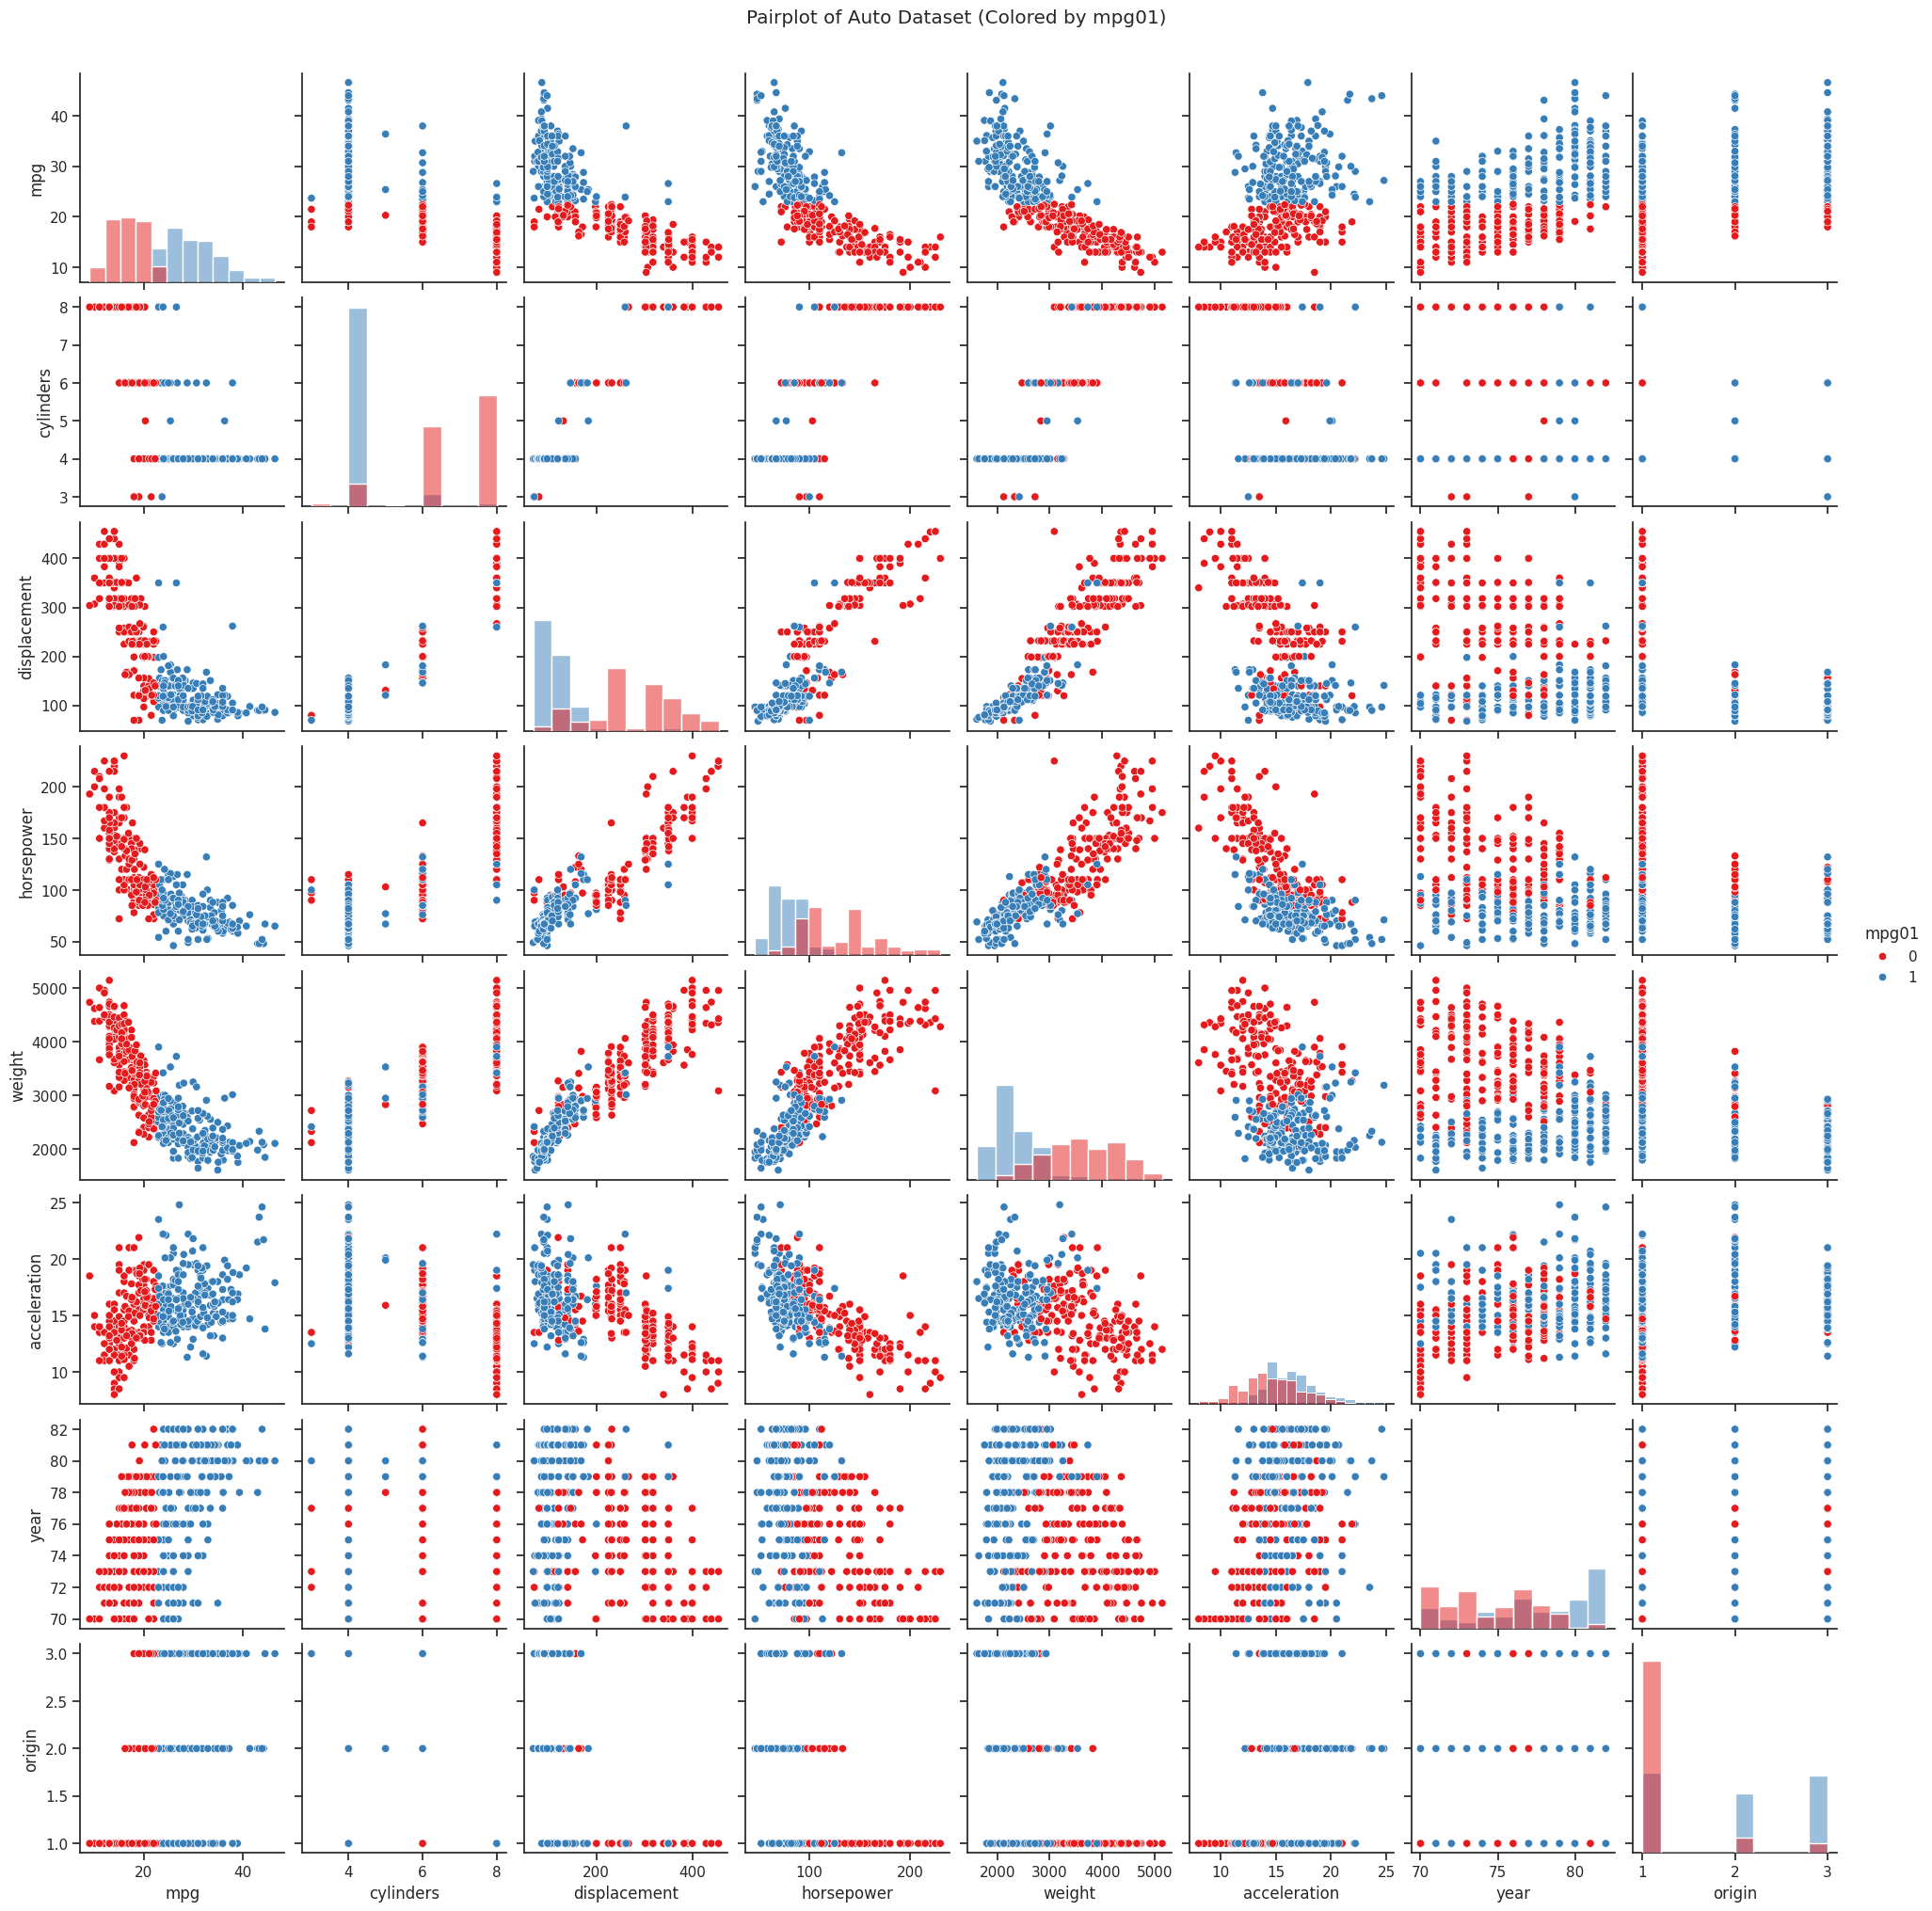

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="ticks")

cols = ['mpg', 'cylinders', 'displacement', 'horsepower',
        'weight', 'acceleration', 'year', 'origin', 'mpg01']

sns.pairplot(auto[cols], hue='mpg01', palette='Set1', diag_kind='hist')

plt.suptitle('Pairplot of Auto Dataset (Colored by mpg01)', y=1.02)
plt.show()


(c) Split the data into a training set and a test set.

In [36]:
predictors = ['cylinders', 'displacement', 'horsepower',
              'weight', 'year', 'origin']

X = auto[predictors]
y = auto['mpg01']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, random_state=0, stratify=y
)

print(X_train.shape, X_test.shape)


(196, 6) (196, 6)


(d) Perform LDA on the training data in order to predict mpg01
using the variables that seemed most associated with mpg01 in
(b). What is the test error of the model obtained?

In [37]:
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)

y_pred_lda = lda.predict(X_test)
lda_test_error = np.mean(y_pred_lda != y_test)
print("LDA test error:", lda_test_error)


LDA test error: 0.08163265306122448


(e) Perform QDA on the training data in order to predict mpg01
using the variables that seemed most associated with mpg01 in
(b). What is the test error of the model obtained?

In [38]:
qda = QuadraticDiscriminantAnalysis()
qda.fit(X_train, y_train)

y_pred_qda = qda.predict(X_test)
qda_test_error = np.mean(y_pred_qda != y_test)
print("QDA test error:", qda_test_error)


QDA test error: 0.10204081632653061


(f) Perform logistic regression on the training data in order to predict mpg01 using the variables that seemed most associated with
mpg01 in (b). What is the test error of the model obtained?

In [39]:
log_reg = LogisticRegression(max_iter=1000, solver='liblinear')
log_reg.fit(X_train, y_train)

y_pred_log = log_reg.predict(X_test)
log_test_error = np.mean(y_pred_log != y_test)
print("Logistic Regression test error:", log_test_error)


Logistic Regression test error: 0.09693877551020408


(g) Perform naive Bayes on the training data in order to predict
mpg01 using the variables that seemed most associated with mpg01
in (b). What is the test error of the model obtained?

In [40]:
nb = GaussianNB()
nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)
nb_test_error = np.mean(y_pred_nb != y_test)
print("Naive Bayes test error:", nb_test_error)


Naive Bayes test error: 0.08673469387755102


(h) Perform KNN on the training data, with several values of K, in
order to predict mpg01. Use only the variables that seemed most
associated with mpg01 in (b). What test errors do you obtain?
Which value of K seems to perform the best on this data set?

In [41]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

k_values = [1, 3, 5, 7, 9, 11, 15]
knn_errors = {}

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred_knn = knn.predict(X_test_scaled)
    error = np.mean(y_pred_knn != y_test)
    knn_errors[k] = error
    print(f"K={k}, KNN test error: {error}")


K=1, KNN test error: 0.12755102040816327
K=3, KNN test error: 0.10714285714285714
K=5, KNN test error: 0.09693877551020408
K=7, KNN test error: 0.10204081632653061
K=9, KNN test error: 0.10714285714285714
K=11, KNN test error: 0.09693877551020408
K=15, KNN test error: 0.09693877551020408
